<a href="https://colab.research.google.com/github/anferivera/Metodos_Computacionales/blob/main/5_2_MCMC_Monte_Carlo_integration_Marckov_chain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MCMC: Monte Carlo_Marckov Chain

El método de Monte Carlo (MC) es una técnica computacional que utiliza muestreo aleatorio para aproximar soluciones a problemas matemáticos, incluyendo integrales definidas. En Python, se puede implementar este método para calcular integrales generando un gran número de puntos aleatorios dentro de un intervalo dado, evaluando la función en esos puntos, y luego calculando el promedio de los resultados multiplicados por el ancho del intervalo.

El **método de Monte Carlo** es especialmente útil cuando no hay una solución analítica disponible o cuando la función es muy compleja para ser integrada analíticamente.

A **Markov Chain** is a random walk that maintains the **memoryless property**. In other words, each step, or probability, in the system is independent of the previous. In our scenario, each step the drunk man takes maintains the same probability of moving forwards or backwards whether he’s on the cliff’s edge or many steps away from it.

**The Metropolis-Hastings method** instead is ...

History: ...

In [2]:
import numpy as np
import random
import math
import matplotlib.pyplot as plt

## 1. MC Integration technique

INTRODUCTION: In the following example we show how to compute the $\pi$ number using a random set of points. This idea shows how to compute a quantity using random numbers.

$\text{Área del cuadrado}/\text{Área círculo} = \text{All points inside the squared}/\text{All points inside the circle}=N/k$

$$4/\pi(1)^2 = N/k$$

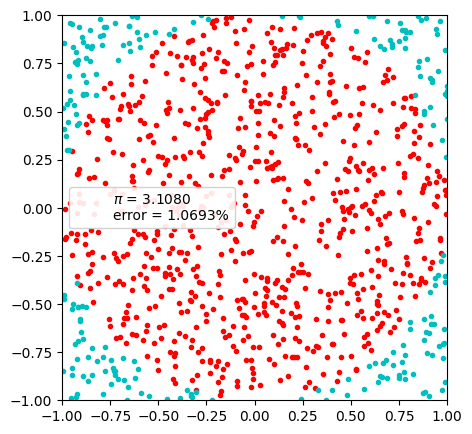

In [7]:
N = 1000
xmenor = []
ymenor = []
xmayor = []
ymayor = []

k=0
x, y = np.random.uniform(-1, 1, size=(2, N)) # Two arrays: N random in (-1,1)

for i in range(N):

  if x[i]**2+y[i]**2 <= 1: # Numbers inside the unitary circle.
    xmenor.append(x[i])
    ymenor.append(y[i])

    #Al the points inside the circle
    k = k+1

  else:
    xmayor.append(x[i])
    ymayor.append(y[i])

#Pi value: Applicaction of the method
pi = k*4/N
error = abs((pi - np.pi) / np.pi)*100
#Ploting
plt.figure(figsize=(5,5))
plt.plot(xmenor, ymenor, 'r.')
plt.plot(xmayor, ymayor, 'c.')
plt.plot(0, 0, label='$\\pi$ = {:4.4f}\nerror = {:4.4f}%'.format(pi,error), alpha=0)
plt.axis('square')
plt.legend(frameon=True, framealpha=0.9, fontsize=10)
plt.xlim(-1,1)
plt.ylim(-1,1)
plt.show()

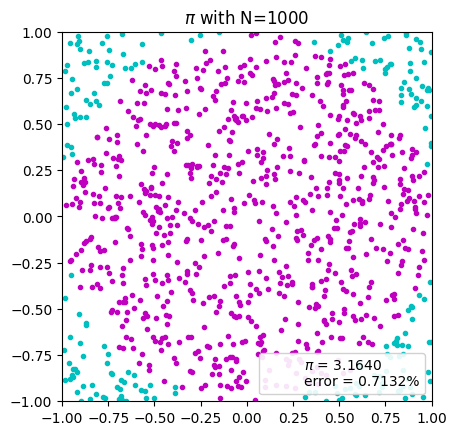

In [39]:
# Ejemplo: Aproximando el valor de pi - área de un círculo de radio = 1. Taken from internet

def mc_pi_aprox(N=1000):
    x, y = np.random.uniform(-1, 1, size=(2, N))
    interior = (x**2 + y**2) <= 1 #if conditional
    pi = interior.sum() * 4/N #suma el contador. Not the sum of the radios
    error = abs((pi - np.pi) / np.pi)*100
    exterior = np.invert(interior)
    plt.plot(x[interior], y[interior], 'm.')
    plt.plot(x[exterior], y[exterior], 'c.')
    plt.plot(0, 0, label='$\\pi$ = {:4.4f}\nerror = {:4.4f}%'.format(pi,error), alpha=0)
    plt.title('$\\pi$ with N=%.d'%N)
    plt.axis('square')
    plt.legend(frameon=True, framealpha=0.9, fontsize=10,loc='lower right')
    plt.xlim(-1,1)
    plt.ylim(-1,1)

mc_pi_aprox()

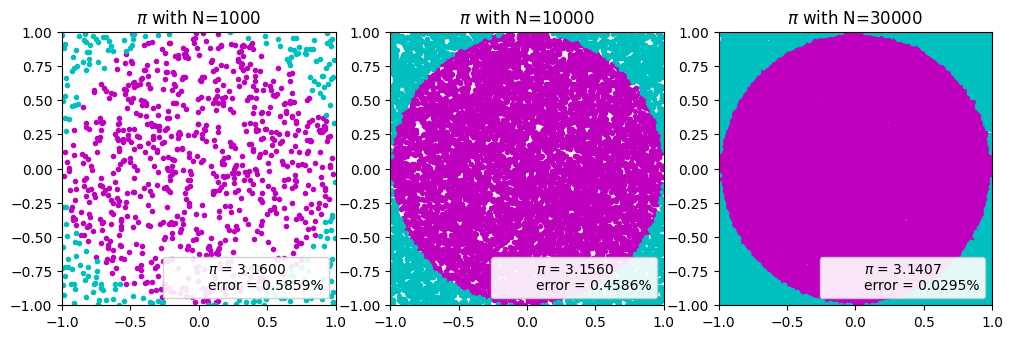

In [46]:
plt.figure(figsize=(12,5))

plt.subplot(131)
mc_pi_aprox(N=1000)

plt.subplot(132)
mc_pi_aprox(N=10000)

plt.subplot(133)
mc_pi_aprox(N=30000)

## Monte Carlo Integration technique

General for compute and integral:

$\int_a^b f(x) dx = \langle f(x) \rangle (b-a) \approx (b-a)\times \sum_{i=1}^N f(x_i)/N$

Idea: $\text{Área promedio} = \text{Área aleatoria / N}$.

In [47]:
#General rutine
def monte_carlo_integration(func, a, b, num_samples=1000):
    """
    Aproxima la integral definida de una función utilizando el método de Monte Carlo.

    Args:
        func: La función a integrar (debe ser una función de Python).
        a: El límite inferior de integración.
        b: El límite superior de integración.
        num_samples: El número de puntos aleatorios a generar.

    Returns:
        Una aproximación de la integral definida.
    """
    integral_sum = 0
    for _ in range(num_samples):
        # Generar un punto aleatorio en el intervalo [a, b]
        x = random.uniform(a, b)
        # Sumar el valor de la función en ese punto
        integral_sum += func(x)
    # Calcular el promedio y multiplicar por el ancho del intervalo
    integral_approx = (b - a) * (integral_sum / num_samples)
    return integral_approx

### Example 1:

$\int_0^2 x^2 dx = (x^{3}/3)|_0^2=8/3≈2.\bar{6}$

In [48]:
import scipy.integrate as integrate

def f(x):
  return x**2

integrate.quad(f,0,2)

(2.666666666666667, 2.960594732333751e-14)

In [49]:
# Example:
def f(x):
    return x**2  # Ejemplo: f(x) = x^2

# Definir los límites de integración y el número de muestras
a = 0
b = 2
num_samples = 20000
integrate.quad(f,0,2)
# Compute the integral using MonteCarlo
integral_result = monte_carlo_integration(f, a, b, num_samples)

print(f"MonteCarlo value: {integral_result}")
print(f"Analytical result : {8/3}")
print('error', abs(integral_result-8/3))

MonteCarlo value: 2.666503274985186
Analytical result : 2.6666666666666665
error 0.00016339168148071792


In [50]:
for i in range(500,10000,1000):
    # Calcular la aproximación de la integral
    integral_result = monte_carlo_integration(f, a, b, i)
    print(i,'samples:',f"Aproximación de la integral: {integral_result}")

print(f"\nAnalytical value: {8/3}")

500 samples: Aproximación de la integral: 2.5817389425729265
1500 samples: Aproximación de la integral: 2.710028786232561
2500 samples: Aproximación de la integral: 2.6298266088905593
3500 samples: Aproximación de la integral: 2.654005452131872
4500 samples: Aproximación de la integral: 2.631532502801068
5500 samples: Aproximación de la integral: 2.684749731502206
6500 samples: Aproximación de la integral: 2.6801621755585154
7500 samples: Aproximación de la integral: 2.7106068987544574
8500 samples: Aproximación de la integral: 2.660707455669507
9500 samples: Aproximación de la integral: 2.648093853492722

Analytical value: 2.6666666666666665


### Example 2:

$\int_0^{\pi}\, \sin(x) dx = (-\cos(x))|_0^{\pi}=2$ ... using MC.

https://www.geeksforgeeks.org/python/monte-carlo-integration-in-python/

In [51]:
def f(x):
    return np.sin(x)

integral_result = monte_carlo_integration(f, 0, np.pi, 3000)

print(f"Aproximation with MC: {integral_result}")

Aproximation with MC: 1.9904224413315499


In [52]:
for i in range(10):
  print(monte_carlo_integration(f, 0, np.pi, 2000))

2.03408993316827
1.9939499485658043
1.9618850529833596
2.03102210261625
1.9735699686523447
1.9839973273811682
1.9998967858757104
2.0313934240367795
1.9818156752149914
2.0033462068100194


The value is very close to the answer of the integral which is 2.0.

- - -

### Histogram

Now if we want to visualize the integration using a histogram, we can do so by using the matplotlib library. Again we import the modules, define the limits of integration and write the sin function for calculating the sin value for a particular value of x. Next, we take an array that has variables representing every beam of the histogram. Then we iterate through N values and repeat the same process of creating a zeros array, filling it with random x values, creating an integral variable adding up all the function values, and getting the answer N times, each answer representing a beam of the histogram. The code is as follows:

The value of the integral is= 2.005112783447649


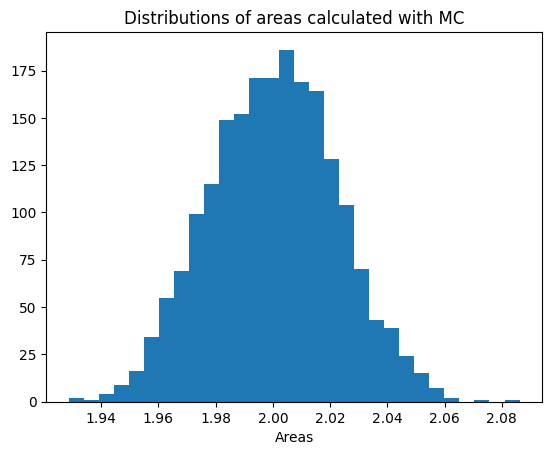

In [53]:
# importing the modules
#from scipy import random
#import numpy as np
#import matplotlib.pyplot as plt

# limits of integration
a, b, N, num_samples = 0, np.pi, 2000, 2000

# function
def f(x):
    return np.sin(x)

# list to store all the values for plotting
plt_vals = []

# we iterate through all the values to generate
# multiple results and show whose intensity is the most.
for i in range(N):

    #Compute the value of the integral for i-esimo time
    ans = monte_carlo_integration( f, a, b, num_samples)

    # appends the solution to a list for plotting the graph
    plt_vals.append(ans)

print('The value of the integral is=',ans)

# details of the plot to be generated
plt.title("Distributions of areas calculated with MC")
plt.hist (plt_vals, bins=30, ec="black")
plt.xlabel("Areas")
plt.show()

In summary, the algorith compute the integral N times and in the mayority of cases the value is near the central value 2. The histogram show the behaviour.

- - -

## Es una cadena de Marcov:

...

```
# This is formatted as code
```



### Metodo de Metropolis-Hastings

Uno de los métodos MCMC más populares es el algoritmo Metropolis-Hastings; de hecho la mayoría de los algoritmos de MCMC pueden ser interpretados como casos especiales de este algoritmo. El algoritmo Metropolis-Hastings esta catalogado como uno de los 10 algoritmos más importantes y más utilizados en ciencia e ingeniería en los últimos veinte años. Se encuentra en el corazón de la mayoría de los métodos de muestreo MCMC. **El problema básico que intenta resolver el algoritmo Metropolis-Hastings es proporcionar un método para generar muestras de alguna distribución genérica $P(x)$.
La idea es que en muchos casos, podemos saber cómo escribir la ecuación para la distribución de probabilidad $P(x)$, pero no sabemos cómo generar muestras aleatorias de la misma**. Entonces la idea básica detrás de este algoritmo es la de construir una cadena de Markov cuya distribución invariante sea la distribución de muestreo que deseamos, es decir $P(x)$. En principio, esto puede parecer bastante complicado, pero la flexibilidad inherente en la elección de las probabilidades de transición lo hacen más simple de lo que parece.

¿cómo funciona? ver:
https://relopezbriega.github.io/blog/2017/01/10/introduccion-a-los-metodos-de-monte-carlo-con-python/

In [ ]:
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt

Normal distribution:

$p(x;\mu,\sigma^2)=\dfrac{1}{\sigma \sqrt{2\pi}} e^{-\dfrac{1}{2}\left(\dfrac{x-μ}{\sigma}\right)^2}$

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html

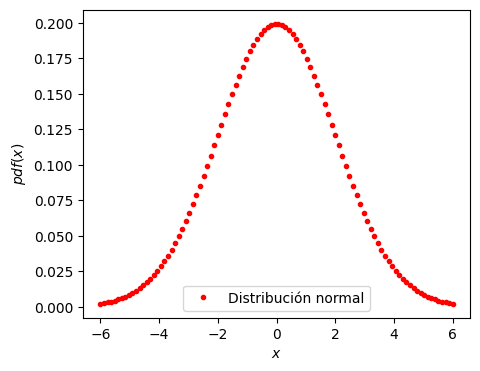

In [ ]:
x = np.linspace(-6, 6, 100)
y = norm(0, 2).pdf(x) #mu=mean es 1 y sigma es 2
#figure
plt.figure(figsize=(5,4))
plt.plot(x, y, 'r.', lw=3, label='Distribución normal')
plt.xlabel('$x$', fontsize=10)
plt.ylabel('$pdf(x)$', fontsize=10)
plt.legend(fontsize=10)
plt.show()

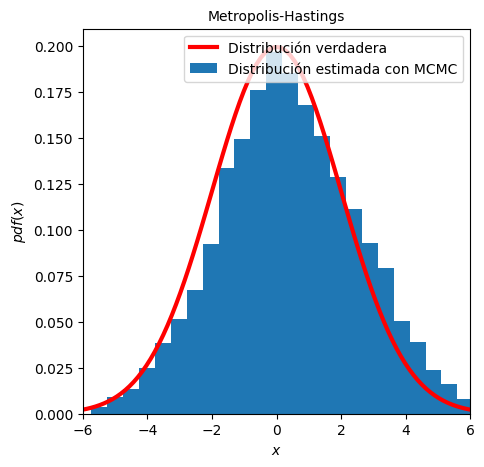

In [ ]:
from scipy.stats import norm
#*****************************************
#     Algorith: Metropolis-Hasting
#*****************************************
def metropolis(func, steps=10000):
    """A very simple Metropolis implementation"""
    muestras = np.zeros(steps)
    old_x = func.mean()
    old_prob = func.pdf(old_x)

    for i in range(steps):
        new_x = old_x + np.random.normal(0, 0.5)
        new_prob = func.pdf(new_x)
        aceptacion = new_prob / old_prob
        if aceptacion >= np.random.random():
            muestras[i] = new_x
            old_x = new_x
            old_prob = new_prob
        else:
            muestras[i] = old_x

    return muestras

# distribución normal
func = norm(0, 2)
samples = metropolis(func=func)#read the normal distribution
x = np.linspace(-6, 7, 100)
y = func.pdf(x)
plt.figure(figsize=(5,5))
plt.xlim(-6, 6)
plt.plot(x, y, 'r-', lw=3, label='Distribución verdadera')
plt.hist(samples, bins=30, density=True, label='Distribución estimada con MCMC')
plt.xlabel('$x$', fontsize=10)
plt.ylabel('$pdf(x)$', fontsize=10)
plt.title('Metropolis-Hastings', fontsize=10)
plt.legend(fontsize=10)
plt.show()

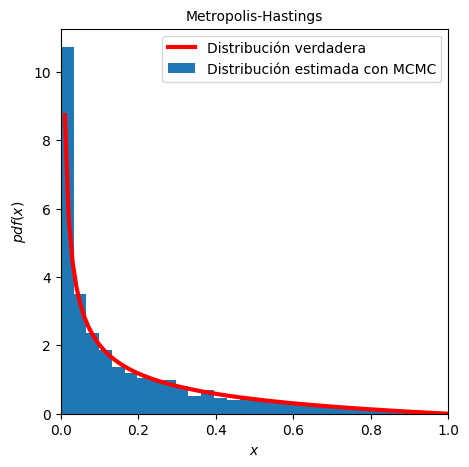

In [ ]:
# distribución beta
from scipy.stats import beta
func = beta(0.4, 2)

samples = metropolis(func=func)
x = np.linspace(0, 1, 100)
y = func.pdf(x)
plt.figure(figsize=(5,5))
plt.xlim(0, 1)
plt.plot(x, y, 'r-', lw=3, label='Distribución beta verdadera')
plt.hist(samples, bins=30, density=True, label='Distribución estimada con MCMC')
plt.xlabel('$x$', fontsize=10)
plt.ylabel('$pdf(x)$', fontsize=10)
plt.title('Metropolis-Hastings', fontsize=10)
plt.legend(fontsize=10)
plt.show()

**Ejemplo** Básico en Python **(Metropolis para una distribución normal**):

El método Metropolis-Hastings en Python utiliza cadenas de Markov para generar muestras aleatorias de una distribución de probabilidad compleja. Es un algoritmo MCMC (Markov Chain Monte Carlo) que acepta o rechaza nuevos estados basados en la razón de densidades de probabilidad, útil en física, estadística bayesiana y optimización.

(array([0.00031798, 0.        , 0.        , 0.00063597, 0.00063597,
        0.        , 0.00127194, 0.00381581, 0.0041338 , 0.00731364,
        0.00858558, 0.01589922, 0.020351  , 0.02321286, 0.03020852,
        0.04833363, 0.06709472, 0.07281844, 0.09412339, 0.10461688,
        0.12115207, 0.14150307, 0.16439795, 0.17330152, 0.1961964 ,
        0.19428849, 0.19905826, 0.19683237, 0.19492446, 0.17234756,
        0.16121811, 0.13959517, 0.12496788, 0.11479238, 0.09094355,
        0.06932061, 0.06009906, 0.04769767, 0.02957255, 0.02543875,
        0.02066899, 0.01303736, 0.0101755 , 0.00794961, 0.00286186,
        0.00095395, 0.00127194, 0.00095395, 0.        , 0.00095395]),
 array([-8.32953212, -8.01505132, -7.70057052, -7.38608972, -7.07160891,
        -6.75712811, -6.44264731, -6.12816651, -5.81368571, -5.49920491,
        -5.18472411, -4.87024331, -4.55576251, -4.24128171, -3.92680091,
        -3.61232011, -3.29783931, -2.98335851, -2.66887771, -2.35439691,
        -2.03991611, -1.72

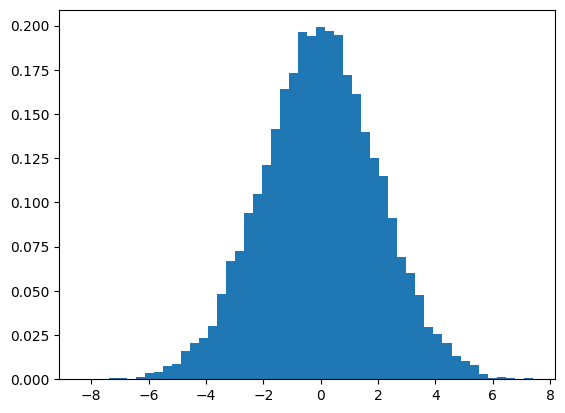

In [ ]:
#x = np.linspace(-6, 6, 1000)
y = np.random.normal(0,2,10000)
#plt.plot(x, y, 'r.', lw=3, label='Distribución normal')
plt.hist(y, bins=50,  density=True)

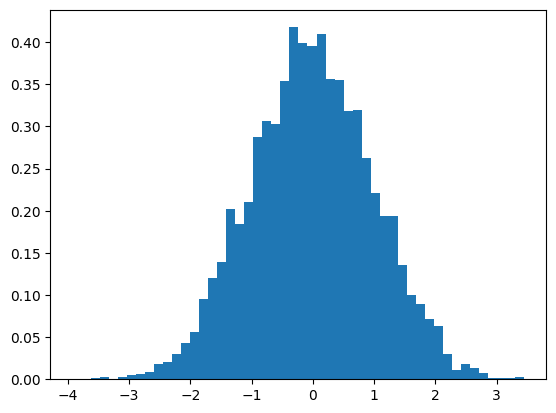

In [ ]:
#**********************************
#   Version 1
#**********************************
import numpy as np
import matplotlib.pyplot as plt

# Definir la distribución objetivo (ej. una distribución normal)
def objetivo(x):
    return np.exp(-0.5 * x**2) # Gaussiana simple

# Algoritmo de Metropolis
def metropolis(n_iter=10000, sigma=1.0):
    x = 0.0 # Estado inicial
    muestras = []
    for _ in range(n_iter):
        x_prop = x + np.random.normal(0, sigma) # Proponer nuevo estado

        # Calcular cociente de aceptación
        p_actual = objetivo(x)
        p_prop = objetivo(x_prop)

        if np.random.rand() < (p_prop / p_actual): #new random
            x = x_prop # Aceptar

        muestras.append(x)
    return np.array(muestras)

# Generar muestras
muestras = metropolis(10000)

# Visualizar resultados
plt.hist(muestras, bins=50, density=True)
plt.show()

## The Drunkard’s Walk ... the random walk

**1D Random Walk**
This example simulates a one-dimensional random walk where a walker starts at a fixed point and moves left or right randomly at each step. The path of the walker is plotted using matplotlib.
https://www.geeksforgeeks.org/python/random-walk-implementation-python/

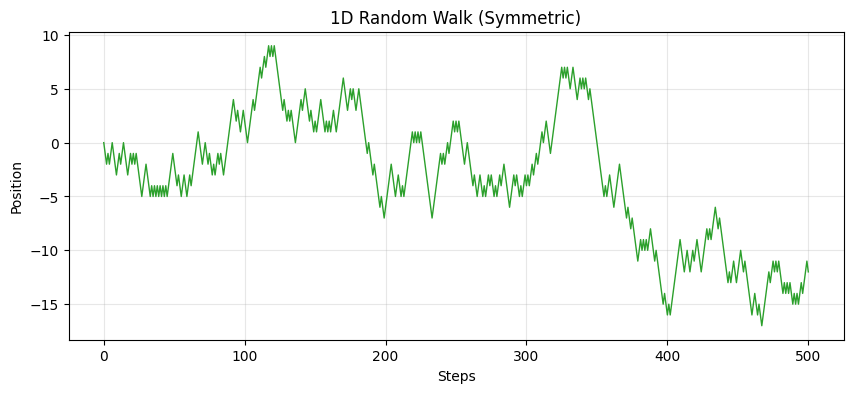

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

steps = 500
origin = 0

step_set = np.array([-1, 1]) # two posible values
random_steps = np.random.choice(step_set, size=steps) # choice between -1 o +1

path = np.concatenate([[origin], np.cumsum(random_steps)]) # np.cumsum suma las numeros del array sucesivamente

plt.figure(figsize=(10, 4))
plt.plot(path, color='#2ca02c', linewidth=1)
plt.title("1D Random Walk (Symmetric)")
plt.xlabel("Steps")
plt.ylabel("Position")
plt.grid(True, alpha=0.3)
plt.show()

Explanation:

* origin = 0 walker starts at position 0.
* step_set = np.array([-1, 1]) each step can be -1 (left) or +1 (right).
* np.random.choice(step_set, size=steps) randomly select steps for the walk.
* np.cumsum(random_steps) compute cumulative sum to get walker’s position at each step.
* plt.plot(path) plot the full random walk path along the number line.

**2D Random Walk in Python**
A 2D random walk lets the walker move in four directions up, down, left or right creating more complex paths compared to 1D. The final path is plotted to visualize the movement on a 2D plane.

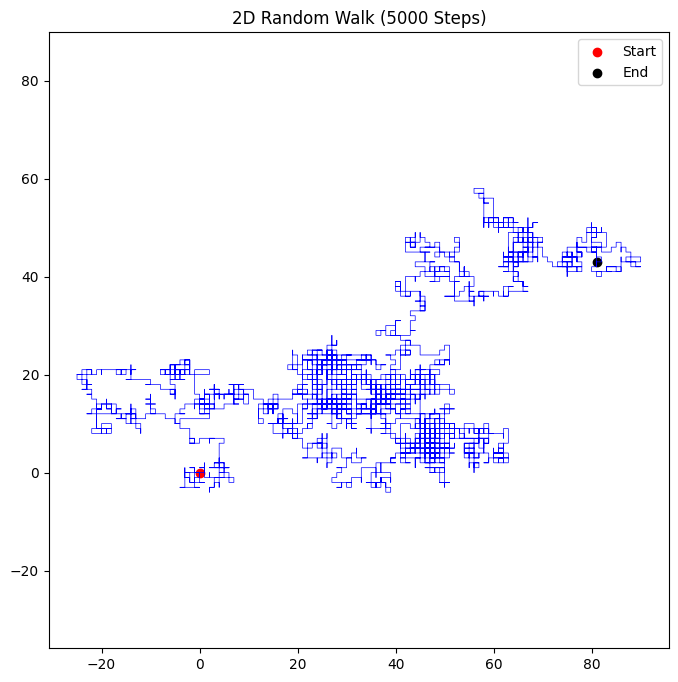

In [ ]:
#import numpy as np
#import matplotlib.pyplot as plt

n = 5000
moves = np.array([(0, 1), (0, -1), (1, 0), (-1, 0)])

random_indices = np.random.choice(len(moves), size=n)
steps = moves[random_indices]

coords = np.cumsum(steps, axis=0)
x, y = coords[:, 0], coords[:, 1]

plt.figure(figsize=(8, 8))
plt.plot(x, y, lw=0.5, color='blue')
plt.scatter(0, 0, color='red', label='Start')
plt.scatter(x[-1], y[-1], color='black', label='End')
plt.title(f"2D Random Walk ({n} Steps)")
plt.legend()
plt.axis('equal')
plt.show()

**Explanation:**

* moves = np.array([(0,1),(0,-1),(1,0),(-1,0)]) define possible moves: up, down, right, left.
* np.random.choice(len(moves), size=n) randomly select n moves.
* steps = moves[random_indices] create sequence of steps for the walk.
* np.cumsum(steps, axis=0) compute cumulative (x, y) positions for the walker.
* plt.plot(x, y) plot the 2D path; plt.scatter marks start (red) and end (black).
* plt.axis('equal') ensures x and y axes have the same scale for accurate visualization.